## Modelado con Gaussian Mixture Model (GMM)


In [30]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import warnings
from math import pi
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler


warnings.filterwarnings('ignore')


### Preparacion de datos

In [77]:

df_dqi =pd.read_csv('./Data/Processed/df_dqi_final.csv', delimiter=';')

'''
df_dqi = df_dqi.drop(columns=['folio_integrante', 'macronutrients_dqi', 'fatty_acids_dqi',
       'balance_dqi', 'empty_calories_dqi', 'total_fat_dqi',
       'saturated_fat_dqi', 'cholesterol_dqi', 'sodium_dqi', 'moderation_dqi',
       'dqi_food_groups', 'dqi_protein_sources', 'variety_dqi',
       'dqi_adequacy_fruits', 'dqi_adequacy_vegetables', 'dqi_adequacy_grains',
       'dqi_adequacy_fiber', 'dqi_adequacy_protein', 'dqi_adequacy_calcium',
       'dqi_adequacy_iron', 'dqi_adequacy_vitamin_c', 'dqi_adecuacy', 'grupo'])

df_dqi = df_dqi.astype(int)
'''

df_dqi = df_dqi.drop(columns=['grupo'])


print("Columnas de df_dqi: ")
print(df_dqi.columns)


Columnas de df_dqi: 
Index(['folio_integrante', 'macronutrients_dqi', 'fatty_acids_dqi',
       'balance_dqi', 'empty_calories_dqi', 'total_fat_dqi',
       'saturated_fat_dqi', 'cholesterol_dqi', 'sodium_dqi', 'moderation_dqi',
       'dqi_food_groups', 'dqi_protein_sources', 'variety_dqi',
       'dqi_adequacy_fruits', 'dqi_adequacy_vegetables', 'dqi_adequacy_grains',
       'dqi_adequacy_fiber', 'dqi_adequacy_protein', 'dqi_adequacy_calcium',
       'dqi_adequacy_iron', 'dqi_adequacy_vitamin_c', 'dqi_adecuacy',
       'dqi_total', 'edad', 'ponderador', 'resultado_general_entrevista',
       'region_Centro', 'region_Centro Norte', 'region_Frontera',
       'region_Pacifico-Norte', 'region_Pacífico Sur',
       'region_Pacífico-Centro', 'region_Península', 'sexo_Mujer',
       'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)'],
      dtype='object')


In [78]:
def gmm(X, clusters):
    silhouette_scores = []

    for cluster in clusters:
        gmm = GaussianMixture(n_components=cluster, random_state=42, max_iter=10000)
        gmm.fit(X)
        labels = gmm.predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
        plot_silhouette(X, labels, cluster)

    return silhouette_scores

def plot_silhouette(X, labels, cluster):
    silhouette_vals = silhouette_samples(X, labels)
    y_lower, y_upper = 0, 0
    n_clusters = np.unique(labels).shape[0]
    plt.figure(figsize=(7, 5))

    for i in range(n_clusters):
        ith_cluster_silhouette_values = silhouette_vals[labels == i]
        ith_cluster_silhouette_values.sort()
        y_upper += len(ith_cluster_silhouette_values)
        color = cm.nipy_spectral(float(i) / n_clusters)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        y_lower = y_upper

    plt.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--")
    plt.title(f'Grafica de silueta para el cluster {cluster}')
    plt.xlabel('Coeficiente de la silueta')
    plt.ylabel('Cluster')
    plt.tight_layout()
    plt.show()

def plot_silhouette_vs_cluster(clusters, silhouette_scores):
    plt.figure(figsize=(8, 6))
    plt.plot(clusters, silhouette_scores, marker='o', linestyle='-', color='b')
    plt.title('Coeficiente de la silueta por clusters')
    plt.xlabel('Clusters')
    plt.ylabel('Coeficiente de la silueta')
    plt.grid(True)
    plt.show()

def plot_centroid_radar(centroides, cluster):
    num_features = centroides.shape[1]
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1] 

    plt.figure(figsize=(8, 8))
    
    for i in range(centroides.shape[0]):
        values = centroides[i].tolist()
        values += values[:1]  
        plt.subplot(1, 1, 1)
        plt.fill(angles, values, alpha=0.25)
        plt.plot(angles, values, label=f'Cluster {i + 1}')

    plt.xticks(angles[:-1], [f'Feature {i + 1}' for i in range(num_features)])
    plt.title(f'Grafica para cluster {cluster}')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()



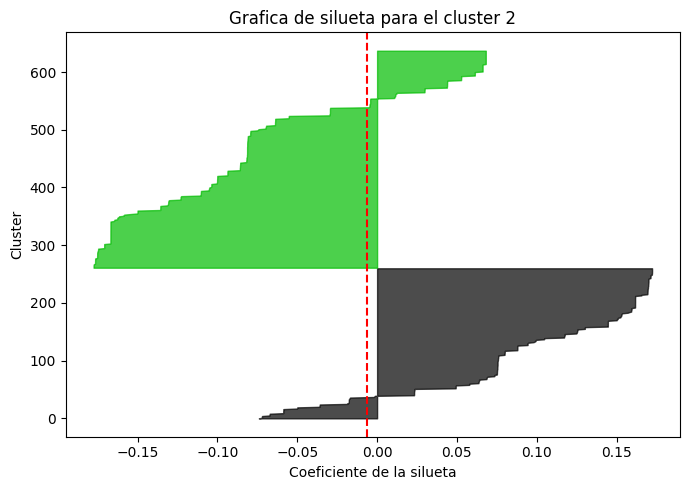

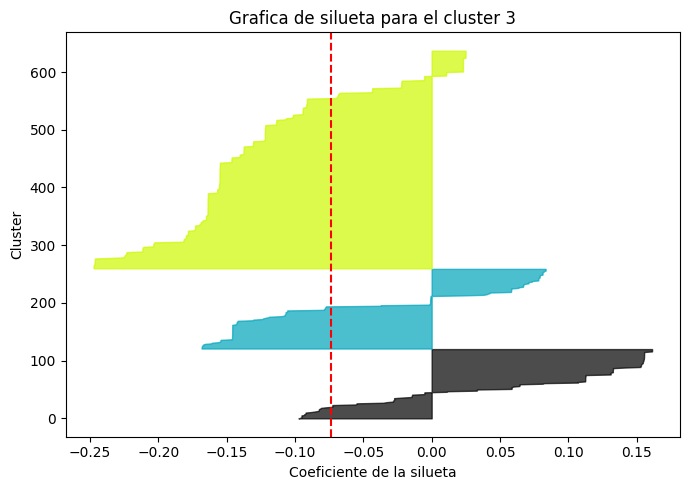

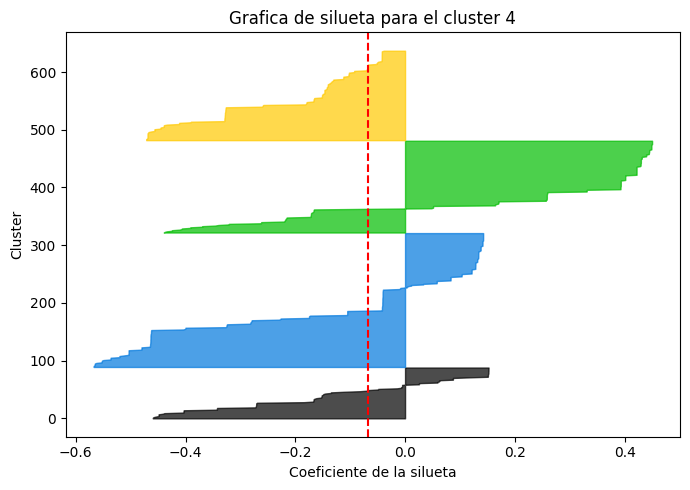

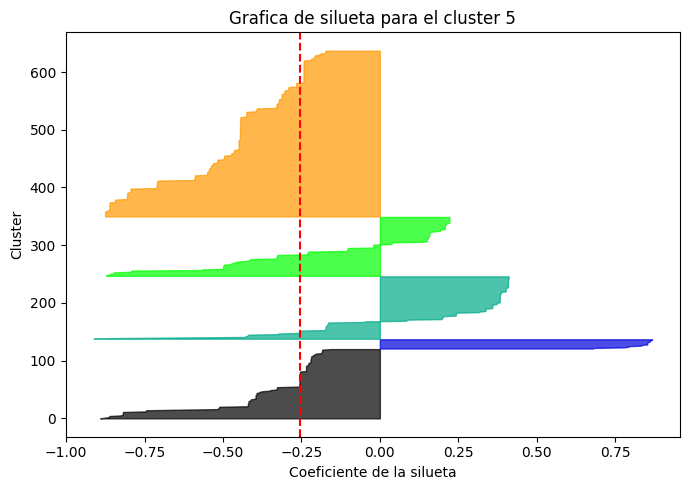

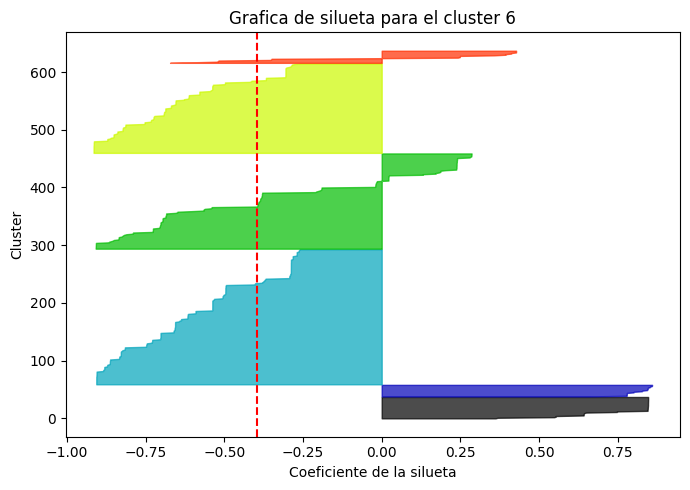

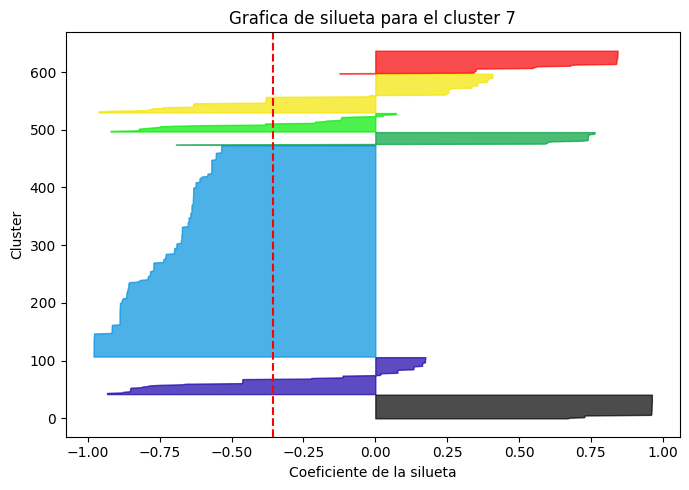

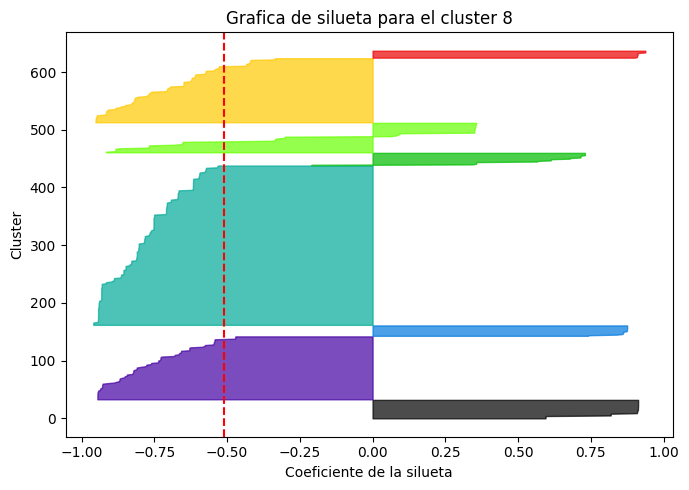

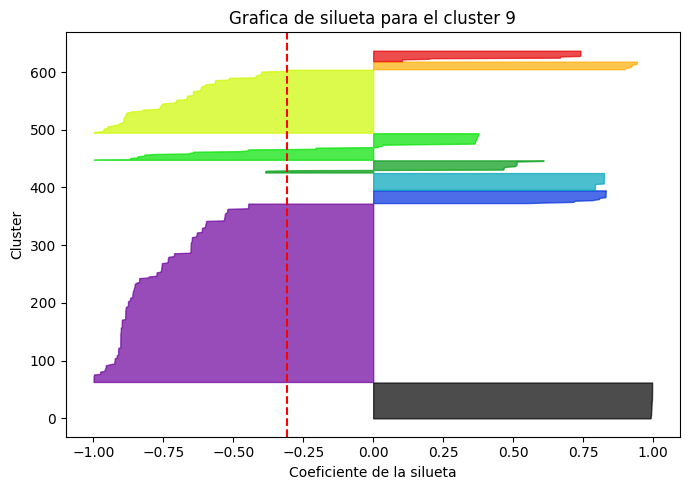

cluster = 2, Puntaje de Silueta = -0.006114403401708785
cluster = 3, Puntaje de Silueta = -0.07365684403869087
cluster = 4, Puntaje de Silueta = -0.06785539125203012
cluster = 5, Puntaje de Silueta = -0.2555739143978546
cluster = 6, Puntaje de Silueta = -0.39490957700437773
cluster = 7, Puntaje de Silueta = -0.35683830740966893
cluster = 8, Puntaje de Silueta = -0.5113650490146457
cluster = 9, Puntaje de Silueta = -0.3082066222235245


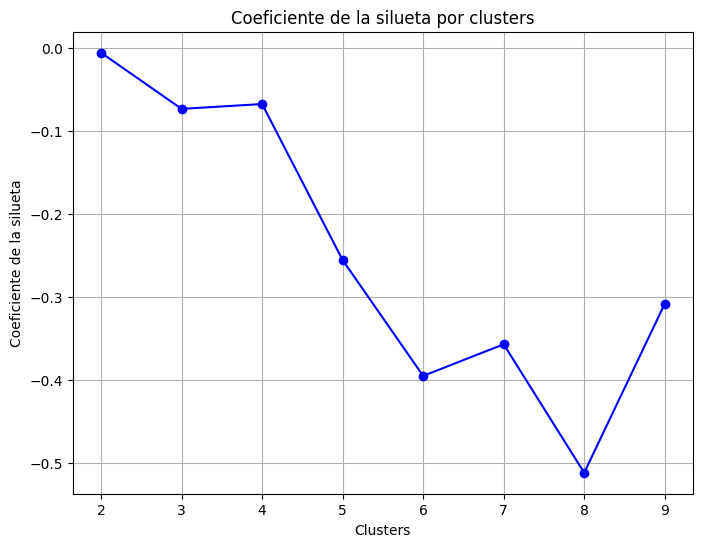

In [79]:
pca = PCA(n_components=10)  
reduced_data = pca.fit_transform(df_dqi)
clusters = range(2, 10)  
puntaje_de_silueta = gmm(reduced_data, clusters)
for cluster, score in zip(clusters, puntaje_de_silueta):
    print(f'cluster = {cluster}, Puntaje de Silueta = {score}')

plot_silhouette_vs_cluster(clusters, puntaje_de_silueta)


In [80]:
def plot_component_spider_plotly(means, n_components):
    num_features = means.shape[1]
    feature_labels = [f'C {i + 1}' for i in range(num_features)]
    data = []
    for i in range(n_components):
        values = means[i].tolist() + [means[i][0]] 
        data.append(values)

    df = pd.DataFrame(data, columns=feature_labels + ['Caracteristica 1'])
    df['componente'] = [f'componente {i + 1}' for i in range(n_components)]
    df = pd.melt(df, id_vars='componente', value_vars=feature_labels, 
                 var_name='Caracteristica', value_name='Valor')
    fig = px.line_polar(df, r='Valor', theta='Caracteristica', color='componente', 
                        line_close=True, title=f'Spider Plot para {n_components} componentes')
    fig.update_traces(fill='toself', opacity=0.25)
    fig.show()
    
    

gmm = GaussianMixture(n_components=9, random_state=42, max_iter=10000)
gmm.fit(reduced_data)
labels = gmm.predict(reduced_data)
plot_component_spider_plotly(gmm.means_,2)
score = silhouette_score(reduced_data, labels)

print(score)


-0.3082066222235245


### Conclusiones del modelo GMM

El data frame usado tiene muchas caracteristicas por lo que se uso PCA para disminuirlas. Como se observa en las graficas del puntaje de la silueta el modelo GMM no da resultados positivos. Es decir, la super posicion entre clusters es muy grande. Incluso en el spider plot se observa como con dos clusters (lo cual ofrece el mejor puntaje de -0.006) se puede observar como es una super posicion muy grande.

Debido a los resultados que arroja el GMM no se recomendia como modelo a usarse para este problema.